### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

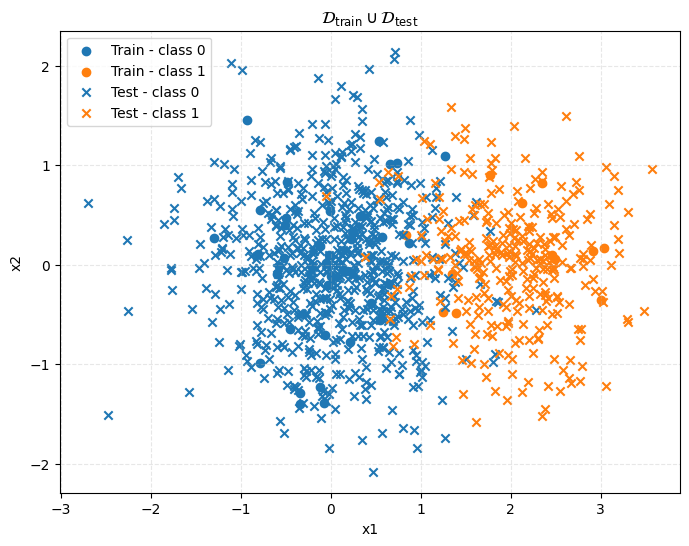

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

def createDataPoints(N,eps,p):
    X = np.zeros((N, 2))
    Y = np.zeros(N)
    for i in range(N):
        U = np.random.rand()

        # y processing 
        y = 0
        if U < p :
            y = 1
        Y[i] = y

        # X processing
        if not(y) :#y=1
            X[i] = np.random.multivariate_normal([0,0],[[0.5,0],[0,0.5]])
        else :
            X[i] = np.random.multivariate_normal([eps,0],[[0.4,0],[0,0.4]])

    return X,Y

X_train, y_train = createDataPoints(50, 2, 0.3)
X_test, y_test =  createDataPoints(10**3, 2, 0.3)

# Plots
plt.figure(figsize=(8, 6))

# Train points
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c="tab:blue", marker="o", label="Train - class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c="tab:orange", marker="o", label="Train - class 1")

# Test points
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c="tab:blue", marker="x", label="Test - class 0")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c="tab:orange", marker="x", label="Test - class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(r"$\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal Bayes classifier is defined as follows:
$$
    f(x) = \mathbb{1}\left(\frac{P(Y = 1 | \mathbf{x})}{P(Y = 0 | \mathbf{x})} > 1\right) \tag{1}
$$

By Bayes formula, we have:

$$
    P(Y = k | \mathbf{x}) = \frac{P(\mathbf{x} | Y = k) P(Y = k)}{P(\mathbf{x})}
    = \frac{p_{\mathcal{N}(\boldsymbol{\mu_k}, \boldsymbol{\Sigma_k})}(\mathbf{x}) p}{P(\mathbf{x})}
    \text{ for } k = 0, 1 \tag{2}
$$ 

We'll compute what's inside the  function of $(1)$.
By taking the $\log$ of $(1)$, we obtain:

$$
    \log \left(p_{\mathcal{N}(\boldsymbol{\mu_1}, \boldsymbol{\Sigma_1})}(\mathbf{x}) \right)
    - \log \left(p_{\mathcal{N}(\boldsymbol{\mu_0}, \boldsymbol{\Sigma_0})}(\mathbf{x}) \right)
    + \log \left(\frac{p}{1 - p}\right) > 0
$$

and then with $(2)$

$$
    \frac{1}{2} \log \left(\frac{\det \Sigma_0}{\det \Sigma_1} \right) - \frac{1}{2} (\mathbf{x} - \mu_1)^\top \Sigma_1 ^ {-1} (\mathbf{x} - \mu_1)
    + \frac{1}{2} (\mathbf{x} - \mu_0)^\top \Sigma_0 ^ {-1} (\mathbf{x} - \mu_0) + \log \left(\frac{p}{1 - p}\right) > 0
$$

Finally, the optimal Bayes classifier is:
$$
\mathbb{1}\left(\frac{1}{2} \log \left(\frac{\det \Sigma_0}{\det \Sigma_1} \right) - \frac{1}{2} (\mathbf{x} - \mu_1)^\top \Sigma_1 ^ {-1} (\mathbf{x} - \mu_1)
    + \frac{1}{2} (\mathbf{x} - \mu_0)^\top \Sigma_0 ^ {-1} (\mathbf{x} - \mu_0) + \log \left(\frac{p}{1 - p}\right) > 0 \right)
$$

The boundary is when it's equal to zero.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Error for epsilon = 2 Bayes :  0.054


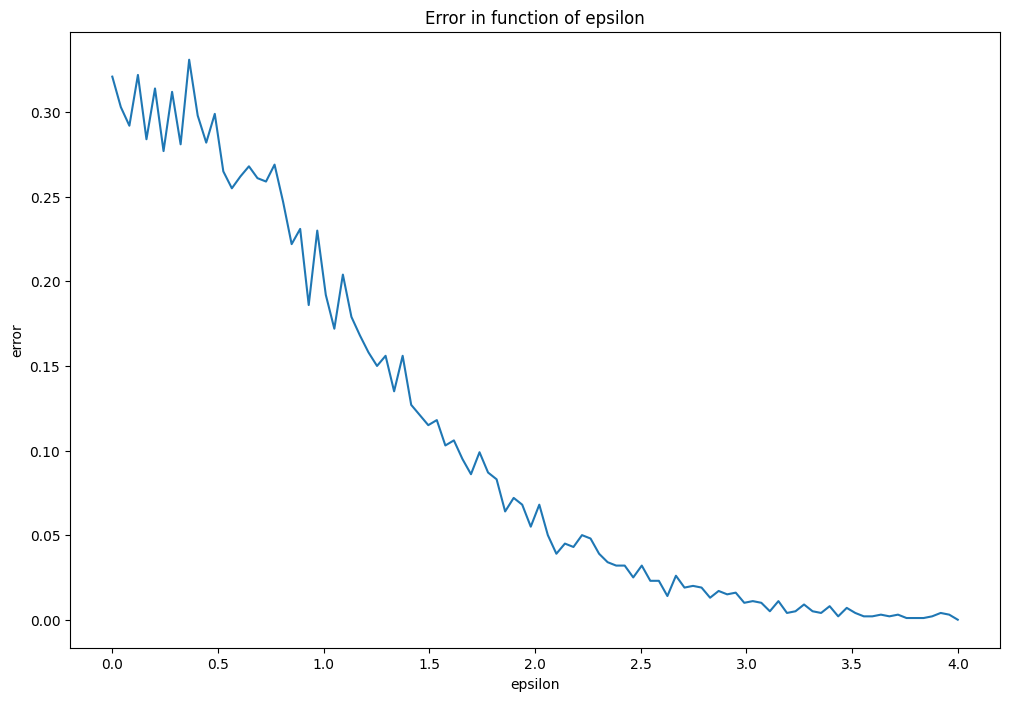

In [2]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import validate_data, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class BayesClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, mu0,  cov0,mu1, cov1, p):
        self.mu0 = mu0
        self.cov0 = cov0
        self.mu1 = mu1
        self.cov1 = cov1
        self.p = p

    def fit(self, X, y):
        X, y = validate_data(self, X, y)
        self.classes_ = unique_labels(y)
    
        self.coefZo = 1 / (2*np.pi*np.sqrt(np.linalg.det(self.cov0)))
        self.coefZ1 = 1 / (2*np.pi*np.sqrt(np.linalg.det(self.cov1)))
        self.cov0Inv = np.linalg.inv(self.cov0)
        self.cov1Inv = np.linalg.inv(self.cov1)
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, reset=False)
        diff0 = X - self.mu0
        diff1 = X - self.mu1
        quad0 = np.einsum("ij,ij->i", diff0 @ self.cov0Inv, diff0)
        quad1 = np.einsum("ij,ij->i", diff1 @ self.cov1Inv, diff1)
        log0 = np.log(1 - self.p) + np.log(self.coefZo) - 0.5 * quad0
        log1 = np.log(self.p) + np.log(self.coefZ1) - 0.5 * quad1
        return np.where(log0 > log1, 0, 1)
    
clf= BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([2, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
)

clf.fit(X_test, y_test)
print("Error for epsilon = 2 Bayes : ", np.mean(clf.predict(X_test) != y_test))


#Error in function of epsilon
epsilon = np.linspace(0, 4, 100)
error_rates = []
for eps in epsilon:
    # Create a new BayesClassifier with the current epsilon
    X_test, y_test =  createDataPoints(10**3, eps, 0.3)
    clf = BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([eps, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
    )
    
    clf.fit(X_test, y_test)
    y_pred = clf.predict(X_test)
    error_rate = np.mean(y_pred != y_test)
    error_rates.append(error_rate)
    
# Plotting the error rates
plt.figure(figsize=(12,8))
plt.plot(epsilon,error_rates)
plt.xlabel("epsilon")
plt.ylabel("error")
plt.title("Error in function of epsilon")
plt.show()




As epsilon increases, it separates the two classes along the x-axis. This means there will be less overlap, so we can more easily deduce which class a point comes from. This is why the error curve decreases.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The datasets are generated by Gaussian distributions  with different covariance matrices. Consequently, the QDA classifiers is the most adequate because it relies on these assumptions.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Error rate for LDA with epsilon = 2  with train size  50 :  0.062
Error rate for QDA with epsilon = 2  with train size  50 :  0.064
Error rate for Logistic Regression with epsilon = 2  with train size  50 :  0.07


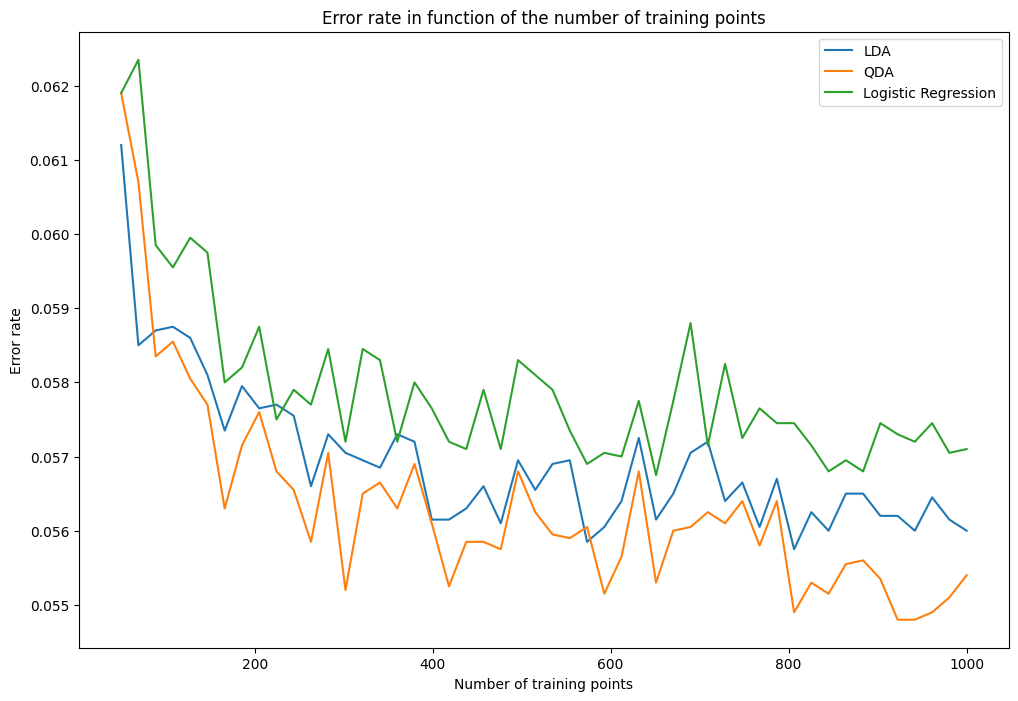

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


eps=2
p=0.3
X_train, y_train = createDataPoints(50,eps,p)
X_test, y_test = createDataPoints(10**3, eps, p) 
clf=LinearDiscriminantAnalysis()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for LDA with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate)
clf=QuadraticDiscriminantAnalysis()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for QDA with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate)
clf=LogisticRegression()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for Logistic Regression with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate) 

#error in function of the number of training points
len_train = np.linspace(50, 1000, 50)
error_rates_lda = []
error_rates_qda = []
error_rates_logistic = []
for n in len_train:
    # Average over multiple runs to smooth the curve
    err_lda, err_qda, err_log= 0, 0, 0
    n_runs = 20
    for _ in range(n_runs):
        X_train, y_train = createDataPoints(int(n), eps, p)
        
        clf=LinearDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_lda += np.mean(clf.predict(X_test) != y_test)
        
        clf=QuadraticDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_qda += np.mean(clf.predict(X_test) != y_test)
        
        clf=LogisticRegression()
        clf.fit(X_train,y_train)
        err_log += np.mean(clf.predict(X_test) != y_test)
        
    error_rates_lda.append(err_lda / n_runs)
    error_rates_qda.append(err_qda / n_runs)
    error_rates_logistic.append(err_log / n_runs)


plt.figure(figsize=(12,8))
plt.plot(len_train,error_rates_lda, label="LDA", color="tab:blue")
plt.plot(len_train,error_rates_qda, label="QDA", color="tab:orange")
plt.plot(len_train,error_rates_logistic, label="Logistic Regression", color="tab:green")
plt.xlabel("Number of training points")
plt.ylabel("Error rate")
plt.title("Error rate in function of the number of training points")
plt.legend()
plt.show()
    

How do their errors compare to the value obtained in (c)?

As we can see, the errors obtained for LDA, QDA, and logistic regression ,with  $\mathcal{D}_{\text{train}}$ and $\mathcal{D}_{\text{test}}$  are higher than the one obtained with our Bayes classifier, but not by much (about +0.025).

Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change?

From the plot, we observe that when the training set is small, all three classifiers have relatively high error rates. As the training set size increases, QDA tends to perform better than LDA. Logistic regression is more variable, but in most cases it remains close to QDA’s error rate. This ranking is consistent with what we would expect from the theoretical assumptions. Empirically, even though the gap between each classifier and the Bayes classifier decreases at first, the curves eventually reach a plateau. The Bayes classifier remains the best.

Theoretically, what is happening?

First, this illustrates the bias–variance trade-off. Training a classifier means estimating parameters from data. Models with more parameters typically have higher variance and therefore require more data to generalize well. Here, even though QDA matches the data-generating assumptions, it has more parameters to estimate than LDA (two covariance matrices instead of one). As a result, with very little data, LDA can sometimes outperform QDA, but as the number of training examples increases, QDA tends to become better.

Second, the plot highlights the difference between generative and discriminative methods. In our setting, the two classes are not heavily overlapping, so a linear decision boundary can already work well, even without explicitly estimating the class-conditional distributions. Moreover, logistic regression has relatively few parameters to estimate, which contributes to its stability.

In conclusion, increasing the size of the training set reduces the gap between the learned classifiers and the optimal (Bayes) classifier. However, some models have an inherent bias and may never reach the Bayes performance, even with a very large amount of data. Finally, both generative and discriminative approaches can approximate the Bayes classifier well, but models with more parameters may need more data before achieving their best performance.


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

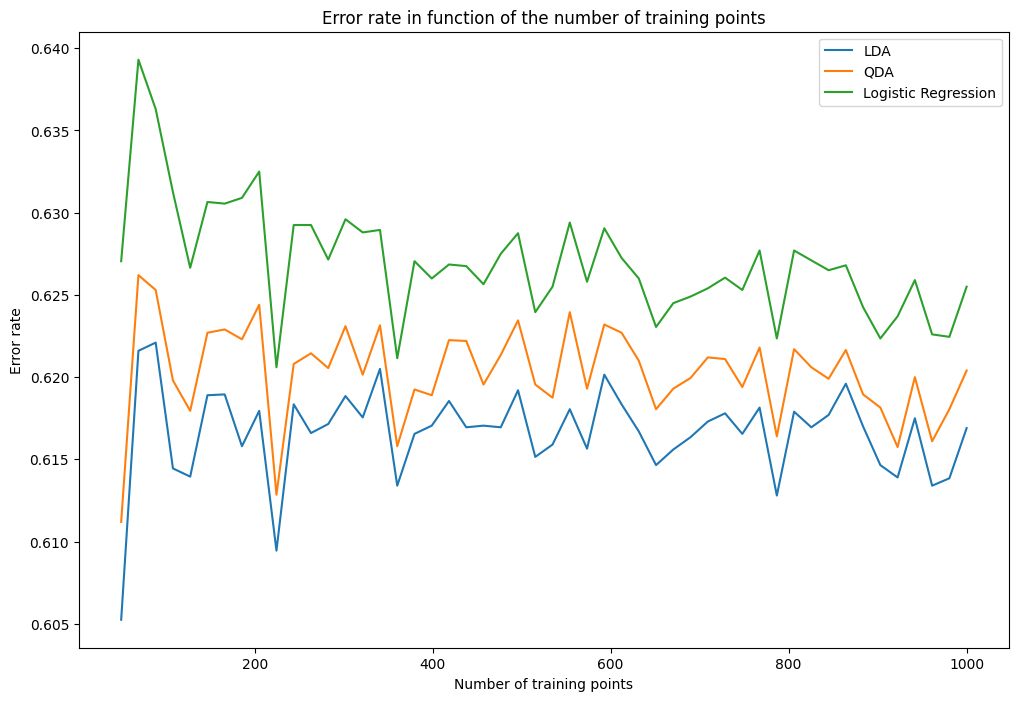

Error for epsilon = 0.5  Bayes:  0.582


In [4]:

X_test, y_test =  createDataPoints(10**3, 0.5, 0.7)

#error in function of the number of training points
len_train = np.linspace(50, 1000, 50)
error_rates_lda = []
error_rates_qda = []
error_rates_logistic = []
for n in len_train:
    # Average over multiple runs to smooth the curve
    err_lda, err_qda, err_log= 0, 0, 0
    n_runs = 20
    for _ in range(n_runs):
        X_train, y_train = createDataPoints(int(n), eps, p)
        
        clf=LinearDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_lda += np.mean(clf.predict(X_test) != y_test)
        
        clf=QuadraticDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_qda += np.mean(clf.predict(X_test) != y_test)
        
        clf=LogisticRegression()
        clf.fit(X_train,y_train)
        err_log += np.mean(clf.predict(X_test) != y_test)
        
    error_rates_lda.append(err_lda / n_runs)
    error_rates_qda.append(err_qda / n_runs)
    error_rates_logistic.append(err_log / n_runs)


plt.figure(figsize=(12,8))
plt.plot(len_train,error_rates_lda, label="LDA", color="tab:blue")
plt.plot(len_train,error_rates_qda, label="QDA", color="tab:orange")
plt.plot(len_train,error_rates_logistic, label="Logistic Regression", color="tab:green")
plt.xlabel("Number of training points")
plt.ylabel("Error rate")
plt.title("Error rate in function of the number of training points")
plt.legend()
plt.show()

clf = BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([0.5, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
    )
clf.fit(X_test, y_test)
print("Error for epsilon = 0.5  Bayes: ", np.mean(clf.predict(X_test) != y_test))


The plot highlights what was discussed in the previous question. Here, since $\varepsilon=0.5$, the two class-conditional distributions overlap more because one of them is translated less along the x-axis. As a result, the setting becomes closer to LDA’s assumptions, and its performance improve relatively to the previous case.

On the other hand, the linear decision boundary of the logistic regression model, trained on the unchanged training dataset, becomes more biased in this new configuration, which explains why its error increases slightly. QDA can also suffer in this regime.

Finally, changing p makes the effect of the change in $\varepsilon$ more visible, since the class that is most affected by this change now has more examples (70%), so the classifiers are evaluated more heavily on this case.

In conclusion, these two modifications explain why the ranking of the curves has changed.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

### Imports

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from skrub import tabular_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

Run this command to submit a prediction directly in the terminal (must have already installed kaggle and generated a Kaggle Token) --> or submit on the Kaggle website
```bash
kaggle competitions submit -c titanic -f ma_prediction.csv -m "Test avec Random Forest"
```

### Upload data

In [6]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Size of the train dataset:", df_train.shape)
print("Size of the test dataset:", df_test.shape)

df_train.head(10)

Size of the train dataset: (891, 12)
Size of the test dataset: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
y_train = df_train["Survived"]
X_train = df_train.drop(columns=["Survived", "PassengerId"])
X_test = df_test.drop(columns=["PassengerId"])

print("Number of NaN values for each row (max 891):")
891 - X_train.count()

Number of NaN values for each row (max 891):


Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [8]:
def export_result_to_csv(y_pred, filename="submission.csv"):
    submission = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": y_pred
    })
    submission.to_csv(filename, index=False)

### Simple model `Skrub`

In [9]:
model = tabular_pipeline("classifier") # use random --> not reproducible results bc not have random_state parameter

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# Export to CSV
export_result_to_csv(y_pred_test, "skrub_model.csv")

`skrub` gave good baseline performance quickly (public score `0.78947`) thanks to automatic preprocessing, encoding and a good model.

However, it remains a generic pipeline: we cannot precisely control domain-specific feature design (for example, custom handling of `Cabin` missingness, engineered `Ticket` structure, or targeted ablation/tuning choices).

So we kept `skrub` as a strong baseline, but our `TitanicLogRegModel` is better suited to the dataset specificities and is easier to optimize with interpretable works.

### With `ColumnTransformer` and `LogisticRegression`

This section defines a reusable model class that always applies a preprocessing pipeline. Hyperparameters are configurable (`rare_deck_threshold`, `rare_ticket_prefix_threshold`, `rare_title_threshold`, and the classifier params).

**Usage Pattern:**
```python
titanic_model = TitanicModel()

titanic_model.fit(X_train, y_train)
predictions = titanic_model.predict(X_test)
y_pred_test = titanic_model.export_csv(predictions, "log_reg.csv")
```

In [20]:
# Titanic model builder and CSV exporter.
def normalize_ticket_prefix(ticket_series):
    prefix = ticket_series.astype(str).str.upper().str.strip()
    prefix = prefix.str.replace(r"\d+", "", regex=True)
    prefix = prefix.str.replace(r"[\s\./]+", "", regex=True)
    return prefix.replace("", "NO_PREFIX")


def extract_title(name_series):
    title = name_series.astype(str).str.extract(r" ([A-Za-z]+)\.", expand=False)
    title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    return title.fillna("Unknown")


def extract_cabin_number(cabin_series):
    return pd.to_numeric(cabin_series.astype(str).str.extract(r"(\d+)", expand=False), errors="coerce")


class TitanicModel(BaseEstimator, ClassifierMixin):
    """
    Titanic survival prediction model.

    Parameters:
    -----------
    rare_deck_threshold : int
        Threshold for grouping rare deck values.
    rare_ticket_prefix_threshold : int
        Threshold for grouping rare ticket prefixes.
    rare_title_threshold : int
        Threshold for grouping rare titles extracted from Name.
    random_state : int
        Random state for reproducibility.
    max_iter : int
        Max iterations for LogisticRegression.
    """

    def __init__(
        self,
        rare_deck_threshold=14,
        rare_ticket_prefix_threshold=1,
        rare_title_threshold=1,
        random_state=1,
        max_iter=1000,
    ):
        self.rare_deck_threshold = rare_deck_threshold
        self.rare_ticket_prefix_threshold = rare_ticket_prefix_threshold
        self.rare_title_threshold = rare_title_threshold
        self.random_state = random_state
        self.max_iter = max_iter

    def fit(self, X, y):
        self.age_group_medians_ = X.groupby(["Sex", "Pclass"])["Age"].median().to_dict()
        self.age_global_median_ = X["Age"].median()
        if pd.isna(self.age_global_median_):
            self.age_global_median_ = 0.0

        self.title_counts_ = extract_title(X["Name"]).value_counts()
        self.rare_titles_ = set(self.title_counts_[self.title_counts_ < self.rare_title_threshold].index)

        deck = X["Cabin"].str.extract(r"([A-Za-z])", expand=False).fillna("U")
        deck_counts = deck.value_counts()
        self.rare_decks_ = set(deck_counts[deck_counts < self.rare_deck_threshold].index)

        ticket_clean = X["Ticket"].astype(str).str.upper().str.strip()
        self.ticket_counts_ = ticket_clean.value_counts()
        ticket_prefix = normalize_ticket_prefix(ticket_clean)
        prefix_counts = ticket_prefix.value_counts()
        self.rare_ticket_prefixes_ = set(prefix_counts[prefix_counts < self.rare_ticket_prefix_threshold].index)

        X_f = self._transform(X)
        self.numeric_cols_ = X_f.select_dtypes(include=["number"]).columns
        self.categorical_cols_ = X_f.select_dtypes(exclude=["number"]).columns

        # change with an other model
        classifier = LogisticRegression(random_state=self.random_state, max_iter=self.max_iter)

        self.pipeline_ = Pipeline([
            ("preprocessor", ColumnTransformer([
                ("num", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]), self.numeric_cols_),
                ("cat", Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]), self.categorical_cols_),
            ], remainder="drop")),
            ("classifier", classifier),
        ])
        self.pipeline_.fit(X_f, y)
        return self

    def _transform(self, X):
        out = X.copy()

        out["Title"] = extract_title(out["Name"])
        out["Title"] = out["Title"].where(~out["Title"].isin(self.rare_titles_), "RareTitle")
        out = out.drop(columns=["Name"])

        out["AgeMissing"] = out["Age"].isna().astype(int)
        group_median = pd.Series(
            [self.age_group_medians_.get((sex, pclass), np.nan) for sex, pclass in zip(out["Sex"], out["Pclass"])],
            index=out.index,
        )
        out["Age"] = out["Age"].fillna(group_median).fillna(self.age_global_median_)

        out["Deck"] = out["Cabin"].str.extract(r"([A-Za-z])", expand=False).fillna("U")
        out["Deck"] = out["Deck"].where(~out["Deck"].isin(self.rare_decks_), "Rare")
        cabin_number = extract_cabin_number(out["Cabin"])
        out["CabinNumber"] = cabin_number.fillna(-1)
        out["CabinNumberOdd"] = np.where(cabin_number.isna(), -1, cabin_number.mod(2)).astype(int)
        out["CabinCount"] = out["Cabin"].fillna("").str.count(r"\S+")
        out = out.drop(columns=["Cabin"])

        ticket_clean = out["Ticket"].astype(str).str.upper().str.strip()
        out["TicketPrefix"] = normalize_ticket_prefix(ticket_clean)
        out["TicketPrefix"] = out["TicketPrefix"].where(~out["TicketPrefix"].isin(self.rare_ticket_prefixes_), "RARE_PREFIX")
        ticket_num = pd.to_numeric(ticket_clean.str.extract(r"(\d+)$")[0], errors="coerce")
        out["TicketNumberMissing"] = ticket_num.isna().astype(int)
        out["TicketNumberLog"] = np.log1p(ticket_num.fillna(0))
        out["TicketGroupSize"] = ticket_clean.map(self.ticket_counts_).fillna(1).astype(float)
        out["FarePerPerson"] = out["Fare"] / out["TicketGroupSize"].replace(0, 1)
        out = out.drop(columns=["Ticket", "Fare"])

        out["FamilySize"] = out["SibSp"] + out["Parch"] + 1

        return out

    def predict(self, X):
        check_is_fitted(self, "pipeline_")
        return self.pipeline_.predict(self._transform(X))

    def export_csv(self, predictions, filename):
        """Generate predictions and export to Kaggle CSV format"""
        export_result_to_csv(predictions, filename=filename)


# Prediction and export to CSV for Kaggle.
titanic_model = TitanicModel()
print("Fitting the model...")
titanic_model.fit(X_train, y_train)
print("✓ Done")

print("Generating predictions on test set and exporting to CSV...")
predictions = titanic_model.predict(X_test)
y_pred_test = titanic_model.export_csv(predictions, "log_reg.csv")
print("✓ Successfully exported predictions to: log_reg.csv")

Fitting the model...
✓ Done
Generating predictions on test set and exporting to CSV...
✓ Successfully exported predictions to: log_reg.csv


**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

We started from a naive baseline (median imputation for numeric features, most-frequent imputation for categorical features), then moved to targeted feature engineering after Exploratory Data Analysis (EDA).

Main engineered features:
- **Age**: add `AgeMissing`, then impute `Age` by median of (`Sex`, `Pclass`) with global fallback.
- **Cabin**: add `Deck`, `CabinNumber`, `CabinNumberOdd`, and `CabinCount`; rare decks are grouped with a CV-tuned threshold.
- **Name**: extract `Title` from `Name`, normalize common variants (`Ms`/`Mlle`/`Mme`), and group rare titles with a tuned threshold.
- **Family structure**: add `FamilySize = SibSp + Parch + 1`.
- **Ticket**: add `TicketPrefix`, `TicketNumberMissing`, `TicketNumberLog`, and `TicketGroupSize`; rare prefixes are grouped with a tuned threshold.
- **Fare**: add `FarePerPerson = Fare / TicketGroupSize` to normalize the fare by shared tickets.

Raw high-cardinality text columns (`Name`, `Cabin`, `Ticket`) are dropped after extraction to reduce sparsity and overfitting (and we dropped also `Fare` because we constructed `FarePerPerson`). Numeric features are scaled; categorical features are one-hot encoded in a `ColumnTransformer` pipeline.

`skrub` remains a strong baseline because it gives good performance quickly with almost no manual work, but its automatic preprocessing is less flexible for dataset-specific feature design. That is why the custom pipeline is still preferable here.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

## Bonus:
- exploration of the data
- cross-validation to determine hyper-parameters

### Exploring the data

#### Cabin number

In [11]:
# Passenger with cabin number
cab = df_train[df_train["Cabin"].notna()].copy()

print(f"With cabin: {len(cab)} / {len(df_train)} ({100*len(cab)/len(df_train):.1f}%)")

def compare_rates(df_all, df_sub, col, bins=None):
    if bins is None:
        s_all = df_all[col]
        s_sub = df_sub[col]
    else:
        s_all = pd.cut(df_all[col], bins=bins, right=False, include_lowest=True)
        s_sub = pd.cut(df_sub[col], bins=bins, right=False, include_lowest=True)

    all_pct = 100 * s_all.value_counts(dropna=False, normalize=True)
    sub_pct = 100 * s_sub.value_counts(dropna=False, normalize=True)

    out = pd.concat(
        [all_pct.rename("all_data_%"), sub_pct.rename("with_cabin_%")],
        axis=1
    ).fillna(0)

    out["delta_pp"] = out["with_cabin_%"] - out["all_data_%"]
    return out.round(2)

for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs with cabin)")
    print(compare_rates(df_train, cab, col).sort_values("delta_pp", ascending=False))

With cabin: 204 / 891 (22.9%)

Pclass (all data vs with cabin)
        all_data_%  with_cabin_%  delta_pp
Pclass                                    
1            24.24         86.27     62.03
2            20.65          7.84    -12.81
3            55.11          5.88    -49.22

Sex (all data vs with cabin)
        all_data_%  with_cabin_%  delta_pp
Sex                                       
female       35.24         47.55     12.31
male         64.76         52.45    -12.31

SibSp (all data vs with cabin)
       all_data_%  with_cabin_%  delta_pp
SibSp                                    
1           23.46         33.82     10.37
2            3.14          2.94     -0.20
3            1.80          1.47     -0.33
5            0.56          0.00     -0.56
8            0.79          0.00     -0.79
4            2.02          0.00     -2.02
0           68.24         61.76     -6.47

Parch (all data vs with cabin)
       all_data_%  with_cabin_%  delta_pp
Parch                               

In [12]:
# Passenger without cabin number
cab = df_train[df_train["Cabin"].isna()].copy()

print(f"Without cabin: {len(cab)} / {len(df_train)} ({100*len(cab)/len(df_train):.1f}%)")

for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs without cabin)")
    print(compare_rates(df_train, cab, col).sort_values("delta_pp", ascending=False))

Without cabin: 687 / 891 (77.1%)

Pclass (all data vs without cabin)
        all_data_%  with_cabin_%  delta_pp
Pclass                                    
3            55.11         69.72     14.62
2            20.65         24.45      3.80
1            24.24          5.82    -18.42

Sex (all data vs without cabin)
        all_data_%  with_cabin_%  delta_pp
Sex                                       
male         64.76         68.41      3.65
female       35.24         31.59     -3.65

SibSp (all data vs without cabin)
       all_data_%  with_cabin_%  delta_pp
SibSp                                    
0           68.24         70.16      1.92
4            2.02          2.62      0.60
8            0.79          1.02      0.23
5            0.56          0.73      0.17
3            1.80          1.89      0.10
2            3.14          3.20      0.06
1           23.46         20.38     -3.08

Parch (all data vs without cabin)
       all_data_%  with_cabin_%  delta_pp
Parch                

#### Observations on missing `Cabin` and preprocessing decisions

Key findings from the outputs above:
- Missing `Cabin` is massive (`687 / 891 = 77.1%`), so dropping rows would remove too much data.
- `Cabin` availability is clearly not random: passengers with known cabins are overrepresented in higher classes and underrepresented in `Pclass=3`.
- This means the **presence/absence** of cabin information already carries signal, even before using the cabin code itself.

Preprocessing implications before modeling:
1. Add `HasCabin = 1(Cabin is not NaN)` to preserve missingness information.
2. Extract deck letter (`Deck`) from `Cabin` (first alphabetical character).
3. Group rare deck categories into `Rare` using a CV-tuned threshold (`rare_deck_threshold`).
4. Add `CabinCount` (number of cabin tokens in the field), which captures potential group booking patterns.
5. Drop raw `Cabin` after feature extraction to avoid noisy high-cardinality strings.

These choices keep the useful structure of `Cabin` while remaining robust to sparsity and missing values.

#### Age

In [13]:
# Passenger with and without known age
def compare_rates_named(df_all, df_sub, col, sub_label, bins=None):
    if bins is None:
        s_all = df_all[col]
        s_sub = df_sub[col]
    else:
        s_all = pd.cut(df_all[col], bins=bins, right=False, include_lowest=True)
        s_sub = pd.cut(df_sub[col], bins=bins, right=False, include_lowest=True)

    all_pct = 100 * s_all.value_counts(dropna=False, normalize=True)
    sub_pct = 100 * s_sub.value_counts(dropna=False, normalize=True)

    sub_col = f"{sub_label}_%"
    out = pd.concat(
        [all_pct.rename("all_data_%"), sub_pct.rename(sub_col)],
        axis=1
    ).fillna(0)

    out["delta_pp"] = out[sub_col] - out["all_data_%"]
    return out.round(2)

df_all_age = df_train.copy()
df_all_age["CabinKnown"] = np.where(df_all_age["Cabin"].notna(), "known", "missing")

age_known = df_all_age[df_all_age["Age"].notna()].copy()
age_missing = df_all_age[df_all_age["Age"].isna()].copy()

print(f"With age: {len(age_known)} / {len(df_all_age)} ({100*len(age_known)/len(df_all_age):.1f}%)")
for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked", "CabinKnown", "Survived"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs with age)")
    print(compare_rates_named(df_all_age, age_known, col, "with_age").sort_values("delta_pp", ascending=False))

print(f"\nWithout age: {len(age_missing)} / {len(df_all_age)} ({100*len(age_missing)/len(df_all_age):.1f}%)")
for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked", "CabinKnown", "Survived"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs without age)")
    print(compare_rates_named(df_all_age, age_missing, col, "without_age").sort_values("delta_pp", ascending=False))

With age: 714 / 891 (80.1%)

Pclass (all data vs with age)
        all_data_%  with_age_%  delta_pp
Pclass                                  
2            20.65       24.23      3.58
1            24.24       26.05      1.81
3            55.11       49.72     -5.39

Sex (all data vs with age)
        all_data_%  with_age_%  delta_pp
Sex                                     
female       35.24       36.55      1.31
male         64.76       63.45     -1.31

SibSp (all data vs with age)
       all_data_%  with_age_%  delta_pp
SibSp                                  
1           23.46       25.63      2.17
4            2.02        2.52      0.50
2            3.14        3.50      0.36
5            0.56        0.70      0.14
3            1.80        1.68     -0.12
8            0.79        0.00     -0.79
0           68.24       65.97     -2.27

Parch (all data vs with age)
       all_data_%  with_age_%  delta_pp
Parch                                  
1           13.24       15.41      2.16
2   

#### Observations on missing `Age` and preprocessing decisions

- Missing `Age` is not random (177 / 891 = 19.9%).
- Passengers without age are overrepresented in:
  - `Pclass=3` (+21.73 pp),
  - `male` (+5.30 pp),
  - `Embarked=Q` (+19.04 pp),
  - `Cabin` missing (+12.16 pp),
  - `Survived=0` (+9.01 pp).
- Therefore, missing `Age` is informative and should be explicitly modeled.

Preprocessing implications before modeling:
1. Add a binary feature `AgeMissing = 1(Age is NaN)`.
2. Impute `Age` conditionally (recommended: median by `Sex x Pclass`; better with `Title x Pclass` if title feature is added).
3. Keep all rows (do not drop missing-age passengers).
4. Optionally test binned age groups (`Child`, `Teen`, `Adult`, `Senior`) and validate with stratified CV.

#### Ticket

In [14]:
# Ticket exploration and candidate feature extraction
ticket = df_train["Ticket"].astype(str).str.upper().str.strip()

ticket_num = pd.to_numeric(ticket.str.extract(r"(\d+)$")[0], errors="coerce")
ticket_prefix = ticket.str.replace(r"\d+", "", regex=True)
ticket_prefix = ticket_prefix.str.replace(r"[\s\./]+", "", regex=True)
ticket_prefix = ticket_prefix.replace("", "NO_PREFIX")

ticket_is_numeric_only = ticket.str.fullmatch(r"\d+")
ticket_group_size = ticket.map(ticket.value_counts())

ticket_df = pd.DataFrame({
    "Ticket": ticket,
    "TicketPrefix": ticket_prefix,
    "TicketNumber": ticket_num,
    "TicketIsNumericOnly": ticket_is_numeric_only.astype(int),
    "TicketGroupSize": ticket_group_size,
    "Survived": y_train.values,
})

print("Rows:", len(ticket_df))
print("Missing Ticket:", ticket_df["Ticket"].isna().sum())
print("Unique Ticket:", ticket_df["Ticket"].nunique())
print(f"Unique ratio: {100*ticket_df['Ticket'].nunique()/len(ticket_df):.1f}%")
print(f"Passengers with shared ticket (group>1): {(ticket_df['TicketGroupSize'] > 1).sum()} / {len(ticket_df)}")

print("\nTicket group size distribution (% of passengers)")
group_dist = 100 * ticket_df["TicketGroupSize"].value_counts(normalize=True).sort_index()
print(group_dist.round(2))

print("\nTop 15 ticket prefixes")
prefix_counts = ticket_df["TicketPrefix"].value_counts()
print(prefix_counts.head(15))
print(f"\nPrefix coverage (not NO_PREFIX): {100*(ticket_df['TicketPrefix'] != 'NO_PREFIX').mean():.1f}%")

print("\nSurvival by TicketIsNumericOnly")
print(ticket_df.groupby("TicketIsNumericOnly")["Survived"].mean().rename("survival_rate").round(4))

print("\nSurvival by ticket group size")
print(
    ticket_df.groupby("TicketGroupSize")["Survived"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
    .round(4)
)

top_prefix = prefix_counts.head(10).index
ticket_df["TicketPrefixTop"] = np.where(
    ticket_df["TicketPrefix"].isin(top_prefix), ticket_df["TicketPrefix"], "OTHER"
)
print("\nSurvival by top ticket prefixes (others grouped)")
print(
    ticket_df.groupby("TicketPrefixTop")["Survived"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .round(4)
)

ticket_num_known = ticket_df[ticket_df["TicketNumber"].notna()].copy()
ticket_num_known["TicketNumberLog"] = np.log1p(ticket_num_known["TicketNumber"])
ticket_num_known["TicketNumBucket"] = pd.qcut(
    ticket_num_known["TicketNumberLog"], q=5, labels=False, duplicates="drop"
)

print("\nSurvival by TicketNumBucket (numeric tickets only, log-quantiles)")
print(
    ticket_num_known.groupby("TicketNumBucket")["Survived"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "survival_rate"})
    .round(4)
)

print("\nExample non-numeric/mixed tickets:")
print(ticket_df.loc[ticket_df["TicketIsNumericOnly"] == 0, "Ticket"].head(12).to_list())


Rows: 891
Missing Ticket: 0
Unique Ticket: 681
Unique ratio: 76.4%
Passengers with shared ticket (group>1): 344 / 891

Ticket group size distribution (% of passengers)
TicketGroupSize
1    61.39
2    21.10
3     7.07
4     4.94
5     1.12
6     2.02
7     2.36
Name: proportion, dtype: float64

Top 15 ticket prefixes
TicketPrefix
NO_PREFIX    661
PC            60
CA            41
A             28
STONO         18
SOTONOQ       15
SCPARIS       11
WC            10
SOC            6
C              5
FCC            5
LINE           4
PP             3
WEP            3
SOPP           3
Name: count, dtype: int64

Prefix coverage (not NO_PREFIX): 25.8%

Survival by TicketIsNumericOnly
TicketIsNumericOnly
0    0.3826
1    0.3843
Name: survival_rate, dtype: float64

Survival by ticket group size
                 count  survival_rate
TicketGroupSize                      
1                  547         0.2980
2                  188         0.5745
3                   63         0.6984
4             

#### Observations on `Ticket` and preprocessing decisions

Key findings from the outputs above:
- `Ticket` has no missing values, but very high cardinality (`681` unique over `891`, i.e. `76.4%`).
- Using raw `Ticket` directly in one-hot encoding is likely too sparse.
- Shared tickets are common (`344/891` passengers have `TicketGroupSize > 1`) and strongly informative:
  - group size `1`: survival around `0.30`,
  - group sizes `2` and `3`: much higher survival rates.
- Prefixes are informative for some groups (`PC` high survival, `A` and `SOTONOQ` low survival), while many prefixes are rare.
- Numeric-only vs non-numeric-only ticket is not informative by itself (very similar survival rates).
- Numeric ticket buckets still carry signal, but should be transformed smoothly (e.g. `log1p`).

Recommended formatting for `Ticket` before modeling:
1. Extract `TicketGroupSize` from exact ticket duplicates.
2. Extract normalized `TicketPrefix` (remove spaces/slashes/dots), then group rare prefixes into `OTHER`/`RARE`.
3. Extract `TicketNumber` (trailing digits), add `TicketNumberMissing`, and use `TicketNumberLog = log1p(TicketNumber)`.
4. Drop raw `Ticket` after feature extraction to avoid sparse overfitting.
5. Build these features inside the CV/pipeline transform logic to avoid data leakage.

### CV to determine hyperparameters

We now tune the rare-category thresholds for `Ticket`, `Deck`, and `Title` using compact grids to keep the notebook efficient.

Top 10 rare_ticket_prefix_threshold values by CV accuracy:
 rare_ticket_prefix_threshold  mean_acc  std_acc
                            1  0.826080 0.044529
                            2  0.824956 0.043372
                            3  0.824956 0.043372
                            4  0.824956 0.043372
                            5  0.824956 0.043372
                            9  0.824956 0.043950
                           10  0.824956 0.043950
                           11  0.824956 0.043950
                           12  0.824956 0.043950
                           13  0.824956 0.043950

Best rare_ticket_prefix_threshold = 1 with mean ± std = 0.8261 ± 0.0445


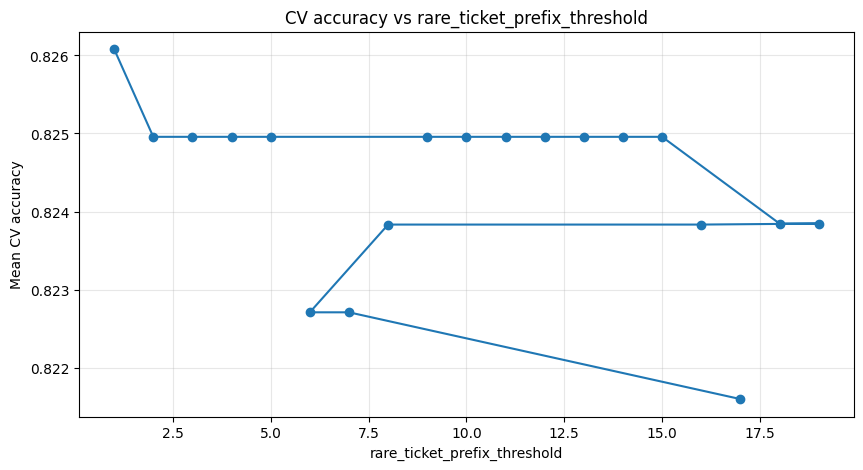

In [15]:
# CV over rare_ticket_prefix_threshold, keeping Cabin and Age fixed.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

ticket_threshold_grid = list(range(1, 20))
ticket_threshold_results = []

for threshold in ticket_threshold_grid:
    model = TitanicModel(
        rare_ticket_prefix_threshold=threshold,
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )
    ticket_threshold_results.append({
        "rare_ticket_prefix_threshold": threshold,
        "mean_acc": scores.mean(),
        "std_acc": scores.std(),
    })

ticket_results_df = pd.DataFrame(ticket_threshold_results).sort_values(["mean_acc", "std_acc"], ascending=[False, True])
best_ticket_row = ticket_results_df.iloc[0]

print("Top 10 rare_ticket_prefix_threshold values by CV accuracy:")
print(ticket_results_df.head(10).to_string(index=False))
print(
    f"\nBest rare_ticket_prefix_threshold = {int(best_ticket_row['rare_ticket_prefix_threshold'])} "
    f"with mean ± std = {best_ticket_row['mean_acc']:.4f} ± {best_ticket_row['std_acc']:.4f}"
)

plt.figure(figsize=(10, 5))
plt.plot(ticket_results_df["rare_ticket_prefix_threshold"], ticket_results_df["mean_acc"], marker="o")
plt.xlabel("rare_ticket_prefix_threshold")
plt.ylabel("Mean CV accuracy")
plt.title("CV accuracy vs rare_ticket_prefix_threshold")
plt.grid(True, alpha=0.3)
plt.show()

Top 10 rare_deck_threshold values by CV accuracy:
 rare_deck_threshold  mean_acc  std_acc
                  14  0.826080 0.044529
                  15  0.826080 0.044529
                  16  0.826080 0.044529
                  17  0.826080 0.044529
                  18  0.826080 0.044529
                  19  0.826080 0.044529
                   1  0.826067 0.042569
                   2  0.826067 0.042569
                   3  0.826067 0.042569
                   4  0.826067 0.042569

Best rare_deck_threshold = 14 with mean ± std = 0.8261 ± 0.0445


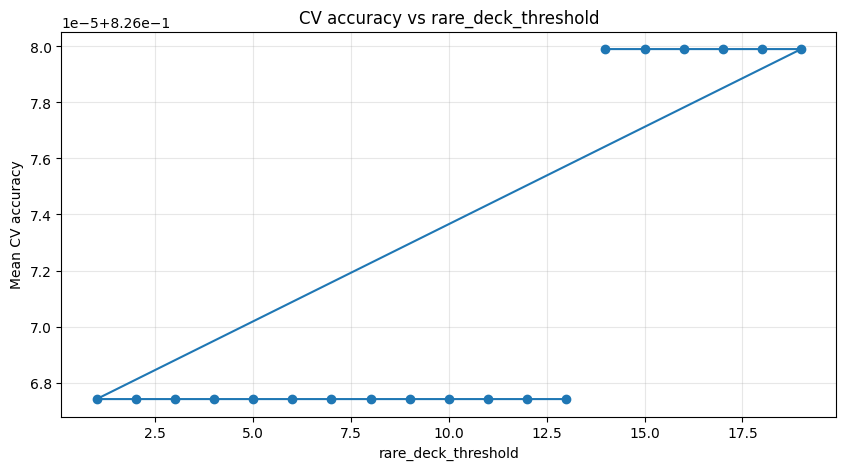

In [16]:
# CV over rare_deck_threshold, keeping Age and Ticket fixed.
deck_threshold_grid = list(range(1, 20))
deck_threshold_results = []

for threshold in deck_threshold_grid:
    model = TitanicModel(
        rare_deck_threshold=threshold,
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )
    deck_threshold_results.append({
        "rare_deck_threshold": threshold,
        "mean_acc": scores.mean(),
        "std_acc": scores.std(),
    })

deck_results_df = pd.DataFrame(deck_threshold_results).sort_values(["mean_acc", "std_acc"], ascending=[False, True])
best_deck_row = deck_results_df.iloc[0]

print("Top 10 rare_deck_threshold values by CV accuracy:")
print(deck_results_df.head(10).to_string(index=False))
print(
    f"\nBest rare_deck_threshold = {int(best_deck_row['rare_deck_threshold'])} "
    f"with mean ± std = {best_deck_row['mean_acc']:.4f} ± {best_deck_row['std_acc']:.4f}"
)

plt.figure(figsize=(10, 5))
plt.plot(deck_results_df["rare_deck_threshold"], deck_results_df["mean_acc"], marker="o")
plt.xlabel("rare_deck_threshold")
plt.ylabel("Mean CV accuracy")
plt.title("CV accuracy vs rare_deck_threshold")
plt.grid(True, alpha=0.3)
plt.show()

Top 10 rare_title_threshold values by CV accuracy:
 rare_title_threshold  mean_acc  std_acc
                    1   0.82608 0.044529
                    3   0.82608 0.044529
                    4   0.82608 0.044529
                    5   0.82608 0.044529
                    6   0.82608 0.044529
                    7   0.82608 0.044529
                    8   0.82608 0.044529
                    9   0.82608 0.044529
                   10   0.82608 0.044529
                   11   0.82608 0.044529

Best rare_title_threshold = 1 with mean ± std = 0.8261 ± 0.0445


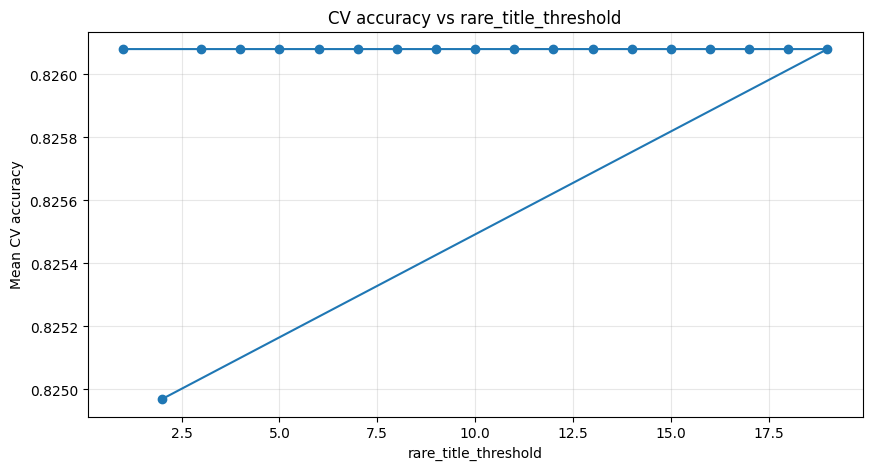

In [17]:
# CV over rare_title_threshold, keeping the other preprocessing fixed.
title_threshold_grid = list(range(1, 20))
title_threshold_results = []

for threshold in title_threshold_grid:
    model = TitanicModel(
        rare_title_threshold=threshold,
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )
    title_threshold_results.append({
        "rare_title_threshold": threshold,
        "mean_acc": scores.mean(),
        "std_acc": scores.std(),
    })

title_results_df = pd.DataFrame(title_threshold_results).sort_values(["mean_acc", "std_acc"], ascending=[False, True])
best_title_row = title_results_df.iloc[0]

print("Top 10 rare_title_threshold values by CV accuracy:")
print(title_results_df.head(10).to_string(index=False))
print(
    f"\nBest rare_title_threshold = {int(best_title_row['rare_title_threshold'])} "
    f"with mean ± std = {best_title_row['mean_acc']:.4f} ± {best_title_row['std_acc']:.4f}"
)

plt.figure(figsize=(10, 5))
plt.plot(title_results_df["rare_title_threshold"], title_results_df["mean_acc"], marker="o")
plt.xlabel("rare_title_threshold")
plt.ylabel("Mean CV accuracy")
plt.title("CV accuracy vs rare_title_threshold")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Final submission model with tuned preprocessing thresholds.
print("Final tuned thresholds:")
print(f"  rare_deck_threshold = {int(best_deck_row['rare_deck_threshold'])}")
print(f"  rare_ticket_prefix_threshold = {int(best_ticket_row['rare_ticket_prefix_threshold'])}")
print(f"  rare_title_threshold = {int(best_title_row['rare_title_threshold'])}")
print()

Final tuned thresholds:
  rare_deck_threshold = 14
  rare_ticket_prefix_threshold = 1
  rare_title_threshold = 1

